<a href="https://colab.research.google.com/github/ninobronw/BPALM-TOOL-IMPLEMENTATION/blob/main/INN_Learner_Notebook_Full_codeJLA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center><font size=6> Bank Churn Prediction </font></center>

## Problem Statement

### Context

Businesses like banks which provide service have to worry about problem of 'Customer Churn' i.e. customers leaving and joining another service provider. It is important to understand which aspects of the service influence a customer's decision in this regard. Management can concentrate efforts on improvement of service, keeping in mind these priorities.

### Objective

You as a Data scientist with the  bank need to  build a neural network based classifier that can determine whether a customer will leave the bank  or not in the next 6 months.

### Data Dictionary

* CustomerId: Unique ID which is assigned to each customer

* Surname: Last name of the customer

* CreditScore: It defines the credit history of the customer.
  
* Geography: A customer’s location
   
* Gender: It defines the Gender of the customer
   
* Age: Age of the customer
    
* Tenure: Number of years for which the customer has been with the bank

* NumOfProducts: refers to the number of products that a customer has purchased through the bank.

* Balance: Account balance

* HasCrCard: It is a categorical variable which decides whether the customer has credit card or not.

* EstimatedSalary: Estimated salary

* isActiveMember: Is is a categorical variable which decides whether the customer is active member of the bank or not ( Active member in the sense, using bank products regularly, making transactions etc )

* Exited : whether or not the customer left the bank within six month. It can take two values
** 0=No ( Customer did not leave the bank )
** 1=Yes ( Customer left the bank )

## Importing necessary libraries

In [1]:
##Installing the libraries with the specified versions
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.4 flask==3.1.1 -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.3/103.3 kB 4.1 MB/s eta 0:00:00


## Loading the dataset

In [64]:
import pandas as pd
data = pd.read_csv("/content/sample_data/bank-1.csv")

# Preview the first 5 rows
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Data Overview

In [4]:
# Dataset dimensions
print("Dimensions:", data.shape)

# Column information
data.info()

# Descriptive statistics
print(data.describe())

# Check for missing values
print("\nMissing values per column:")
print(data.isnull().sum())


Dimensions: (10000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
         RowNumber    CustomerId   CreditScore           Age        Te

## Exploratory Data Analysis

### Univariate Analysis

Distribution of 'Exited' variable:
Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


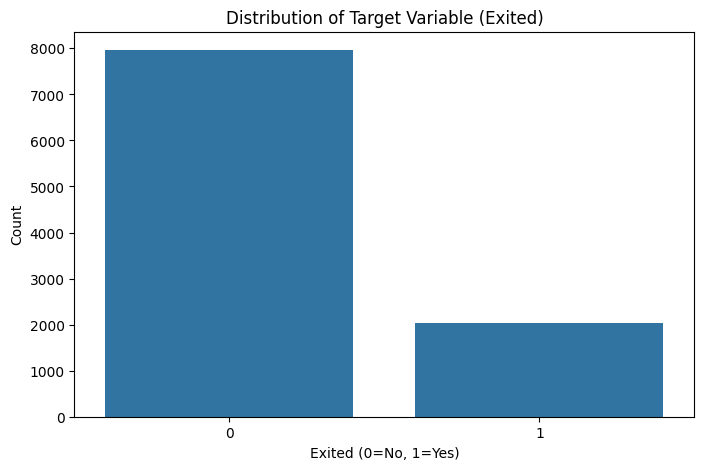

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

# Target variable: distribution and statistics
print("Distribution of 'Exited' variable:")
print(data['Exited'].value_counts(normalize=True))

plt.figure(figsize=(8, 5))
sns.countplot(x='Exited', data=data)
plt.title("Distribution of Target Variable (Exited)")
plt.xlabel("Exited (0=No, 1=Yes)")
plt.ylabel("Count")
plt.show()

Distribution of 'Exited' variable:
Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


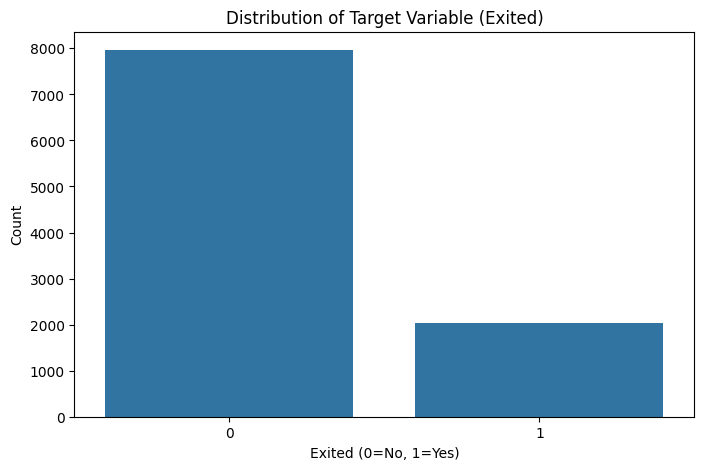

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Target variable: distribution and statistics
print("Distribution of 'Exited' variable:")
print(data['Exited'].value_counts(normalize=True))

plt.figure(figsize=(8, 5))
sns.countplot(x='Exited', data=data)
plt.title("Distribution of Target Variable (Exited)")
plt.xlabel("Exited (0=No, 1=Yes)")
plt.ylabel("Count")
plt.show()

### Univariate Analysis of Categorical Features

/tmp/ipykernel_837/4278952286.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Geography', data=data, palette='viridis')


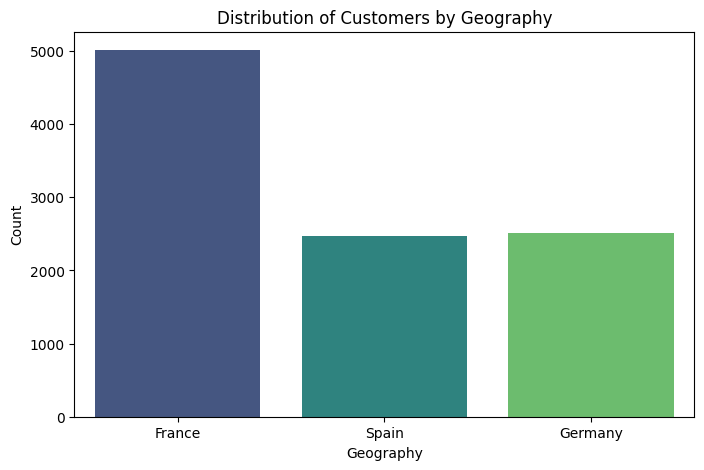

In [11]:
# Analyze 'Geography' distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='Geography', data=data, palette='viridis')
plt.title("Distribution of Customers by Geography")
plt.xlabel("Geography")
plt.ylabel("Count")
plt.show()

/tmp/ipykernel_837/786843524.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=data, palette='coolwarm')


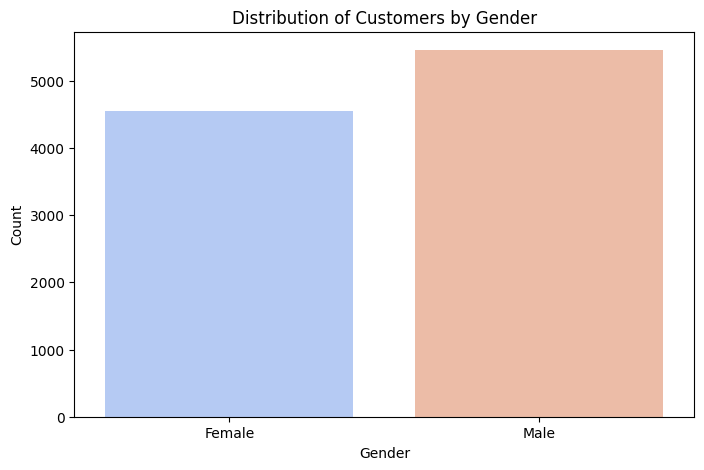

In [16]:
# Analyze 'Gender' distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='Gender', data=data, palette='coolwarm')
plt.title("Distribution of Customers by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

/tmp/ipykernel_837/1458815557.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='HasCrCard', data=data, palette='pastel')


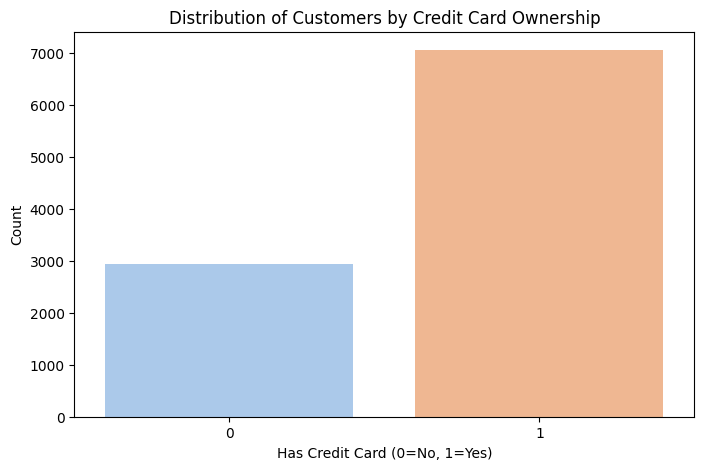

In [19]:
# Analyze 'HasCrCard' distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='HasCrCard', data=data, palette='pastel')
plt.title("Distribution of Customers by Credit Card Ownership")
plt.xlabel("Has Credit Card (0=No, 1=Yes)")
plt.ylabel("Count")
plt.show()

/tmp/ipykernel_837/2309488821.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='IsActiveMember', data=data, palette='deep')


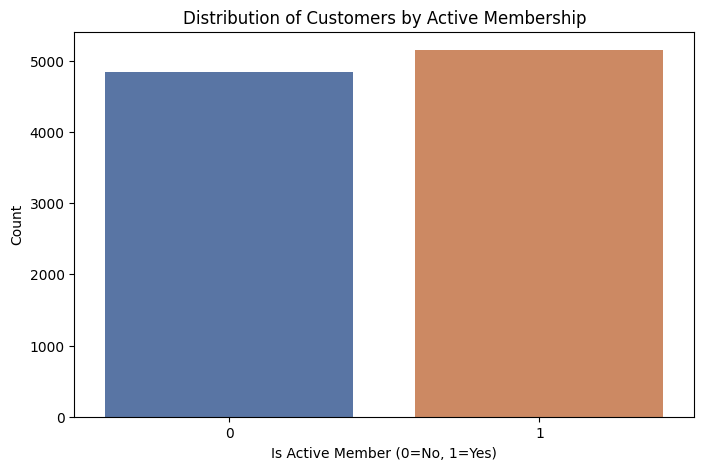

In [10]:
# Analyze 'IsActiveMember' distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='IsActiveMember', data=data, palette='deep')
plt.title("Distribution of Customers by Active Membership")
plt.xlabel("Is Active Member (0=No, 1=Yes)")
plt.ylabel("Count")
plt.show()

/tmp/ipykernel_837/1929823511.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='NumOfProducts', data=data, palette='Set2')


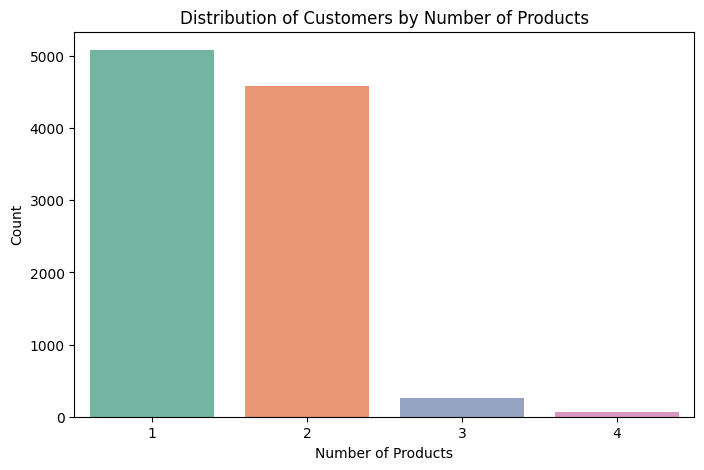

In [12]:
# Analyze 'NumOfProducts' distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='NumOfProducts', data=data, palette='Set2')
plt.title("Distribution of Customers by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Count")
plt.show()

/tmp/ipykernel_837/388227287.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Tenure', data=data, palette='Paired')


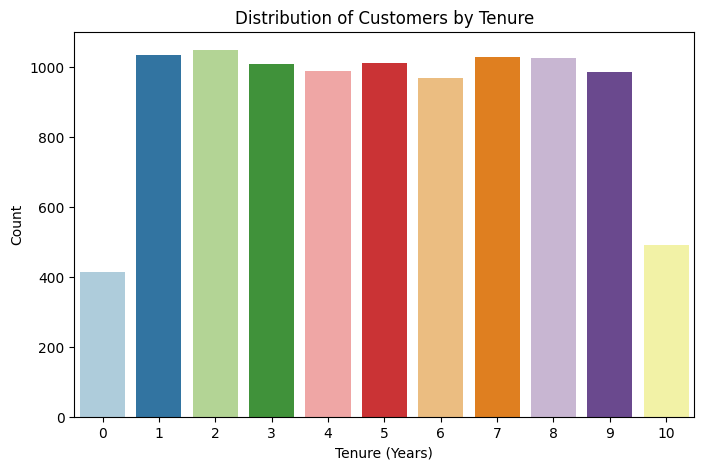

In [20]:
# Analyze 'Tenure' distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='Tenure', data=data, palette='Paired')
plt.title("Distribution of Customers by Tenure")
plt.xlabel("Tenure (Years)")
plt.ylabel("Count")
plt.show()

### Univariate Analysis of Numerical Features

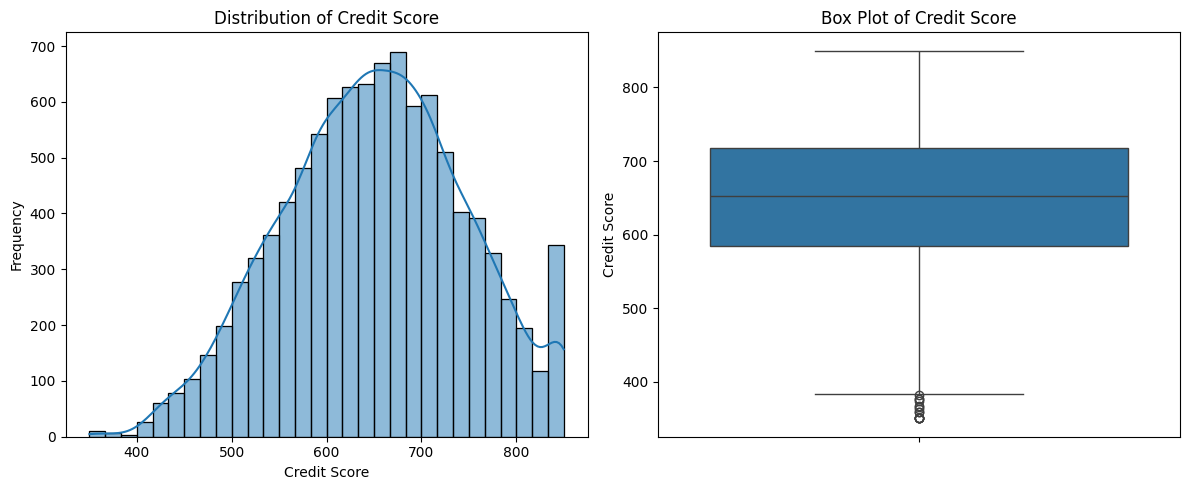

In [21]:
# Analyze 'CreditScore' distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(data['CreditScore'], bins=30, kde=True)
plt.title("Distribution of Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(y=data['CreditScore'])
plt.title("Box Plot of Credit Score")
plt.ylabel("Credit Score")
plt.tight_layout()
plt.show()

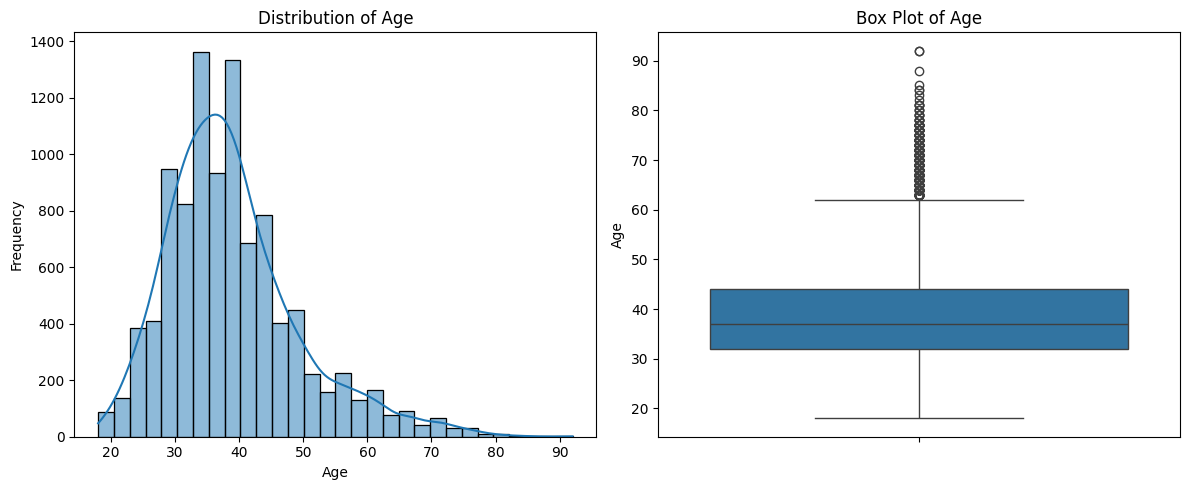

In [15]:
# Analyze 'Age' distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(data['Age'], bins=30, kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(y=data['Age'])
plt.title("Box Plot of Age")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

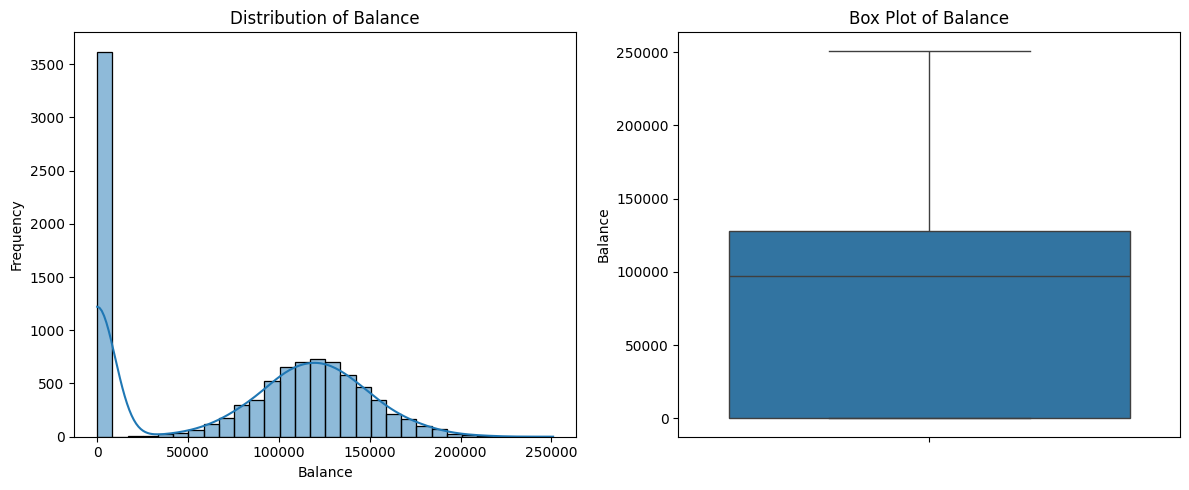

In [17]:
# Analyze 'Balance' distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(data['Balance'], bins=30, kde=True)
plt.title("Distribution of Balance")
plt.xlabel("Balance")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(y=data['Balance'])
plt.title("Box Plot of Balance")
plt.ylabel("Balance")
plt.tight_layout()
plt.show()

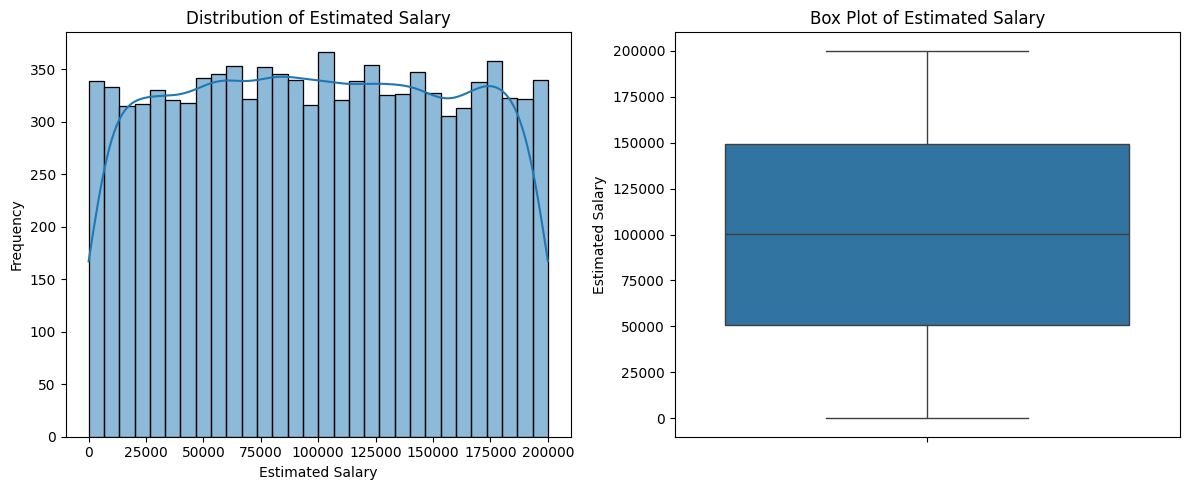

In [18]:
# Analyze 'EstimatedSalary' distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(data['EstimatedSalary'], bins=30, kde=True)
plt.title("Distribution of Estimated Salary")
plt.xlabel("Estimated Salary")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(y=data['EstimatedSalary'])
plt.title("Box Plot of Estimated Salary")
plt.ylabel("Estimated Salary")
plt.tight_layout()
plt.show()

### Bivariate Analysis

In [49]:
# 1. Correlation between numerical variables
plt.figure(figsize=(8, 6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

### Bivariate Analysis: Target Variable vs. Categorical Features

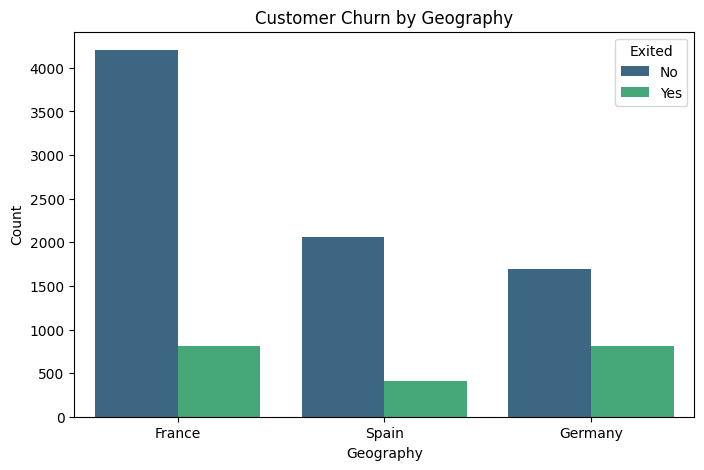

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Exited vs Geography
plt.figure(figsize=(8, 5))
sns.countplot(x='Geography', hue='Exited', data=data, palette='viridis')
plt.title("Customer Churn by Geography")
plt.xlabel("Geography")
plt.ylabel("Count")
plt.legend(title='Exited', labels=['No', 'Yes'])
plt.show()

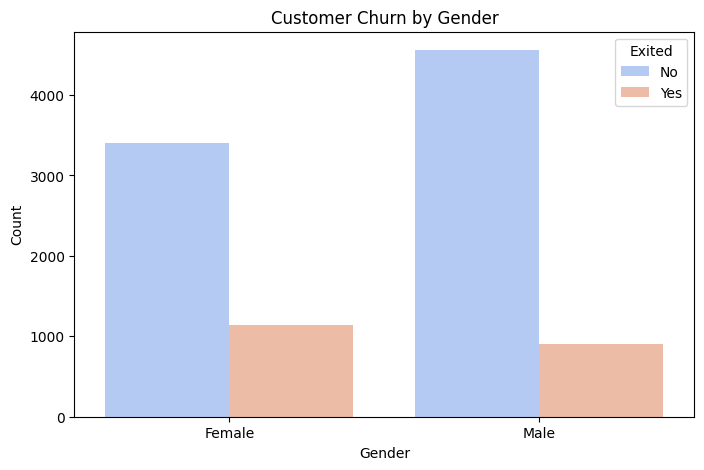

In [36]:
# Exited vs Gender
plt.figure(figsize=(8, 5))
sns.countplot(x='Gender', hue='Exited', data=data, palette='coolwarm')
plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title='Exited', labels=['No', 'Yes'])
plt.show()

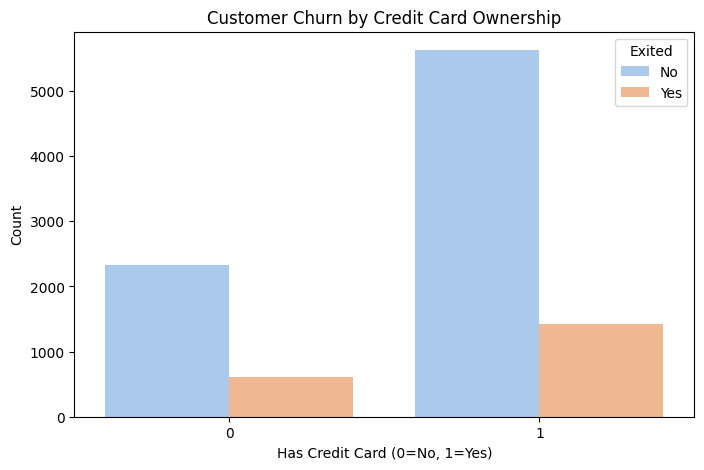

In [37]:
# Exited vs HasCrCard
plt.figure(figsize=(8, 5))
sns.countplot(x='HasCrCard', hue='Exited', data=data, palette='pastel')
plt.title("Customer Churn by Credit Card Ownership")
plt.xlabel("Has Credit Card (0=No, 1=Yes)")
plt.ylabel("Count")
plt.legend(title='Exited', labels=['No', 'Yes'])
plt.show()

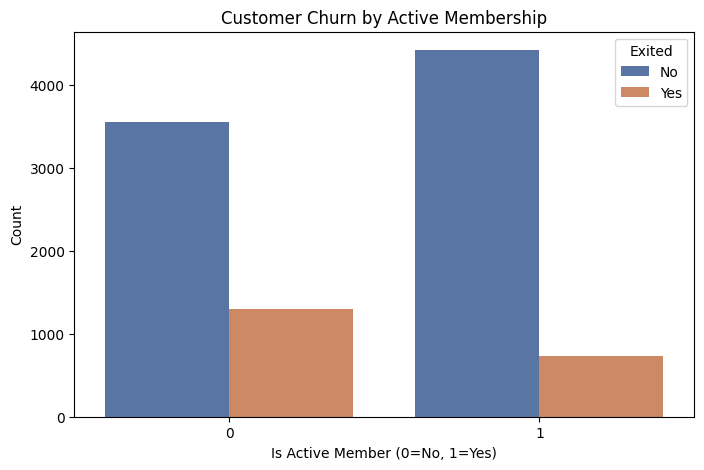

In [38]:
# Exited vs IsActiveMember
plt.figure(figsize=(8, 5))
sns.countplot(x='IsActiveMember', hue='Exited', data=data, palette='deep')
plt.title("Customer Churn by Active Membership")
plt.xlabel("Is Active Member (0=No, 1=Yes)")
plt.ylabel("Count")
plt.legend(title='Exited', labels=['No', 'Yes'])
plt.show()

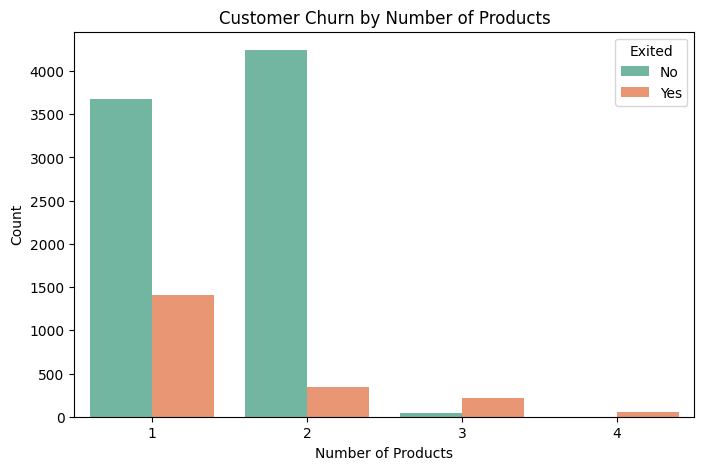

In [39]:
# Exited vs NumOfProducts
plt.figure(figsize=(8, 5))
sns.countplot(x='NumOfProducts', hue='Exited', data=data, palette='Set2')
plt.title("Customer Churn by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Count")
plt.legend(title='Exited', labels=['No', 'Yes'])
plt.show()

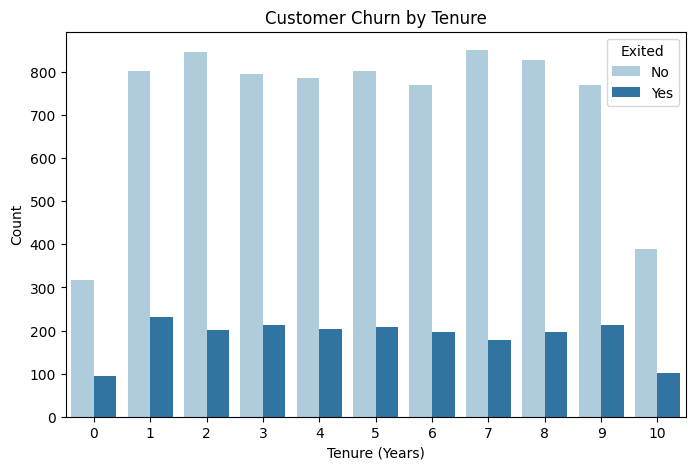

In [40]:
# Exited vs Tenure
plt.figure(figsize=(8, 5))
sns.countplot(x='Tenure', hue='Exited', data=data, palette='Paired')
plt.title("Customer Churn by Tenure")
plt.xlabel("Tenure (Years)")
plt.ylabel("Count")
plt.legend(title='Exited', labels=['No', 'Yes'])
plt.show()

### Bivariate Analysis: Target Variable vs. Numerical Features

/tmp/ipykernel_837/675993587.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y='CreditScore', data=data, palette='coolwarm')


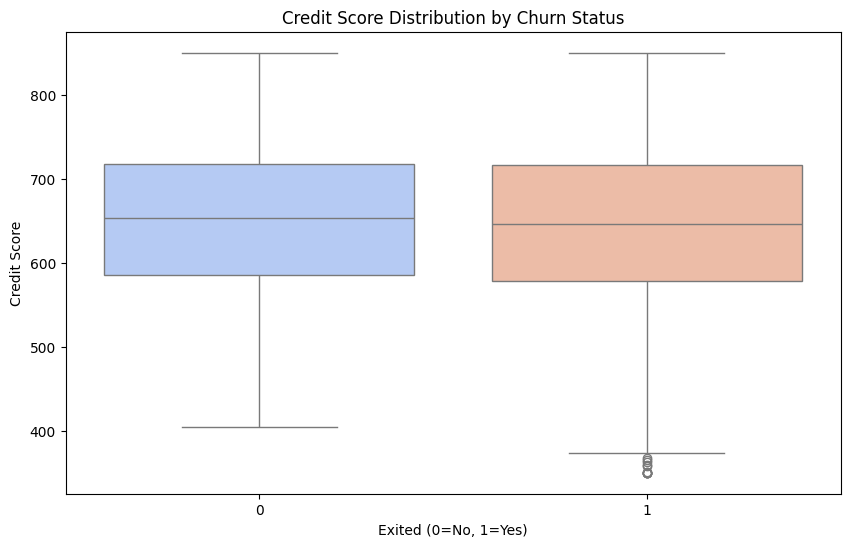

In [41]:
# Exited vs CreditScore
plt.figure(figsize=(10, 6))
sns.boxplot(x='Exited', y='CreditScore', data=data, palette='coolwarm')
plt.title("Credit Score Distribution by Churn Status")
plt.xlabel("Exited (0=No, 1=Yes)")
plt.ylabel("Credit Score")
plt.show()

/tmp/ipykernel_837/2693067725.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y='Age', data=data, palette='viridis')


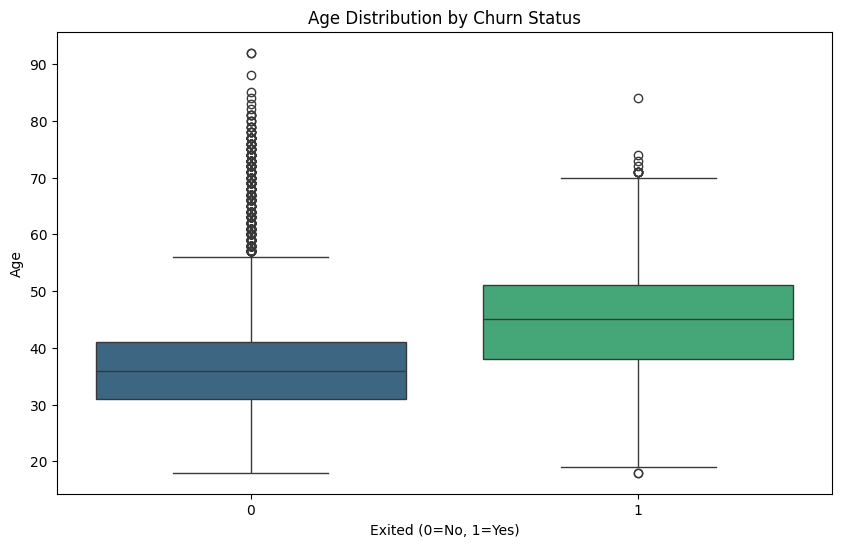

In [42]:
# Exited vs Age
plt.figure(figsize=(10, 6))
sns.boxplot(x='Exited', y='Age', data=data, palette='viridis')
plt.title("Age Distribution by Churn Status")
plt.xlabel("Exited (0=No, 1=Yes)")
plt.ylabel("Age")
plt.show()

/tmp/ipykernel_837/1334998330.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y='Balance', data=data, palette='pastel')


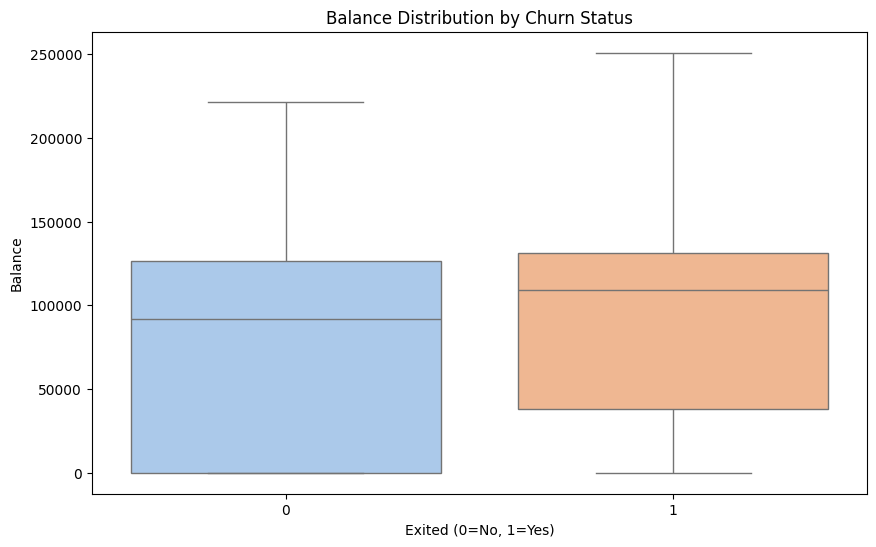

In [43]:
# Exited vs Balance
plt.figure(figsize=(10, 6))
sns.boxplot(x='Exited', y='Balance', data=data, palette='pastel')
plt.title("Balance Distribution by Churn Status")
plt.xlabel("Exited (0=No, 1=Yes)")
plt.ylabel("Balance")
plt.show()

In [60]:
# defining the list of numerical columns
cols_list = ["CreditScore","Age","Tenure","Balance","EstimatedSalary"]

/tmp/ipykernel_837/4212952173.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y='EstimatedSalary', data=data, palette='deep')


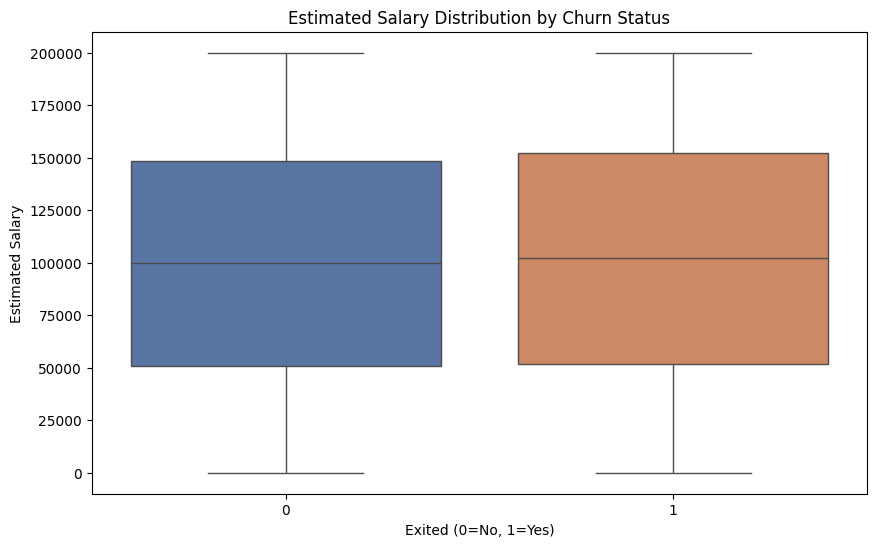

In [44]:
# Exited vs EstimatedSalary
plt.figure(figsize=(10, 6))
sns.boxplot(x='Exited', y='EstimatedSalary', data=data, palette='deep')
plt.title("Estimated Salary Distribution by Churn Status")
plt.xlabel("Exited (0=No, 1=Yes)")
plt.ylabel("Estimated Salary")
plt.show()

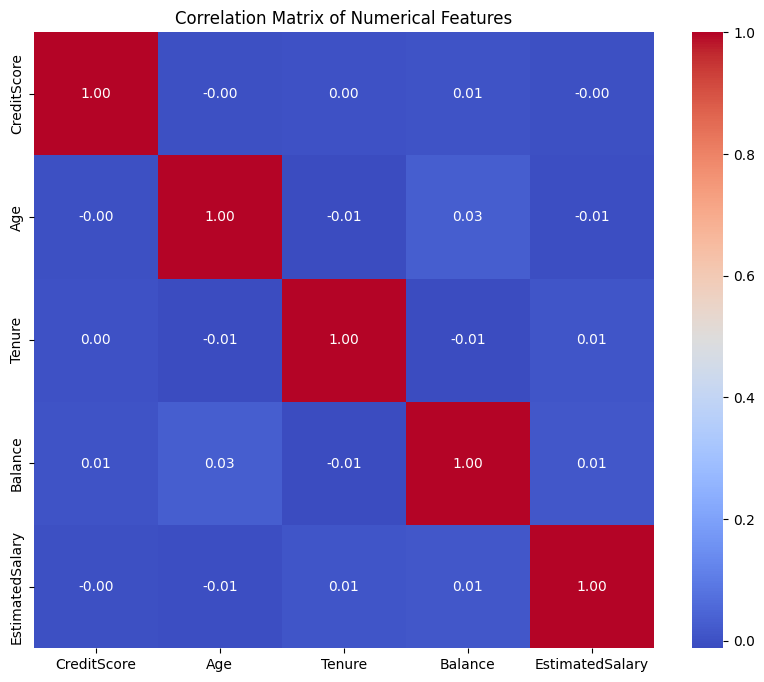

In [61]:
plt.figure(figsize=(10, 8))
sns.heatmap(data[cols_list].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## Data Preprocessing

### Dummy Variable Creation

In [68]:
# Create a list of columns to encode based on what actually exists
cols_to_encode = [col for col in ['Geography', 'Gender', 'geography', 'gender'] if col in data.columns]

# Apply get_dummies only to the existing columns
if cols_to_encode:
    data = pd.get_dummies(data, columns=cols_to_encode, drop_first=True)
else:
    print("Warning: Neither Geography nor Gender columns were found!")


### Train-validation-test Split

In [51]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = data.drop('Exited', axis=1)
y = data['Exited']

# Split data into training (70%), validation (15%), and test (15%) sets
# First, split into train and temp (validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

# Then, split temp into validation and test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (7000, 11)
y_train shape: (7000,)
X_val shape: (1500, 11)
y_val shape: (1500,)
X_test shape: (1500, 11)
y_test shape: (1500,)


### Data Normalization

In [53]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns (excluding dummy variables and the target)
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform all sets
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_val[numerical_cols] = scaler.transform(X_val[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Data after normalization:")
print(X_train.head())

Data after normalization:
      CreditScore       Age    Tenure   Balance  NumOfProducts  HasCrCard  \
9136    -0.575582 -1.796679 -0.349474  0.312906      -0.912483          1   
6410     0.398182  2.269825 -1.386929 -1.223574       0.799493          1   
2607     1.693082 -0.756410 -1.386929  0.682321      -0.912483          1   
3201     0.740036 -1.796679  0.342162 -1.223574       0.799493          1   
3330     0.905783 -1.985818 -0.349474 -1.223574       0.799493          1   

      IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  \
9136               0         1.362512              False            False   
6410               1         1.515472              False             True   
2607               0         0.038955              False            False   
3201               0         1.671444              False            False   
3330               1        -0.899384              False            False   

      Gender_Male  
9136         True  
6410    

### Équilibrage des Données avec SMOTE

Pour gérer le déséquilibre des classes et potentiellement améliorer le rappel du modèle, nous allons utiliser SMOTE (Synthetic Minority Over-sampling Technique) sur les données d'entraînement.

In [63]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Shape of X_train before SMOTE: {X_train.shape}")
print(f"Shape of y_train before SMOTE: {y_train.shape}")
print(f"Shape of X_train after SMOTE: {X_train_res.shape}")
print(f"Shape of y_train after SMOTE: {y_train_res.shape}")

print("Distribution of y_train after SMOTE:")
print(y_train_res.value_counts())

Shape of X_train before SMOTE: (7000, 11)
Shape of y_train before SMOTE: (7000,)
Shape of X_train after SMOTE: (11148, 11)
Shape of y_train after SMOTE: (11148,)
Distribution of y_train after SMOTE:
Exited
0    5574
1    5574
Name: count, dtype: int64


### Build and Train Neural Network Model

In [50]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Define the model architecture
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid') # Output layer for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Define Early Stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32,
                    validation_data=(X_val, y_val), callbacks=[early_stopping], verbose=1)

print("Model training complete.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.7919 - loss: 0.4685 - val_accuracy: 0.8273 - val_loss: 0.3762
Epoch 2/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8354 - loss: 0.3966 - val_accuracy: 0.8513 - val_loss: 0.3497
Epoch 3/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8427 - loss: 0.3810 - val_accuracy: 0.8460 - val_loss: 0.3420
Epoch 4/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8463 - loss: 0.3719 - val_accuracy: 0.8647 - val_loss: 0.3346
Epoch 5/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8470 - loss: 0.3629 - val_accuracy: 0.8640 - val_loss: 0.3343
Epoch 6/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8500 - loss: 0.3628 - val_accuracy: 0.8540 - val_loss: 0.3424
Epoch 7/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8550 - loss: 0.3591 - val_accuracy: 0.8620 - val_loss: 0.3351
Epoch 8/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8590 - loss: 0.3517 - val_ac

### Model Evaluation

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test Accuracy: 0.8660
Test Precision: 0.7574
Test Recall: 0.5016
Test F1-Score: 0.6036
Test ROC AUC: 0.8624


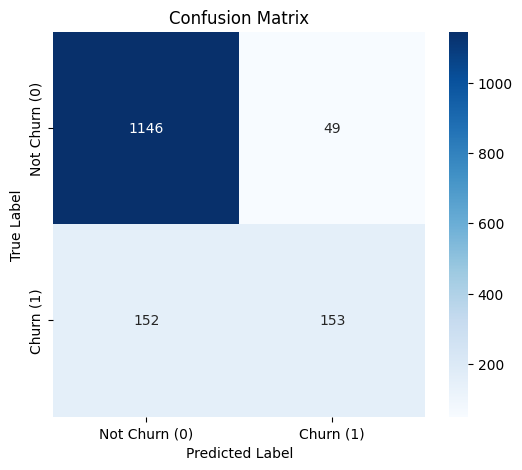

In [56]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np

# Predict probabilities on the test set
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1-Score: {f1:.4f}")
print(f"Test ROC AUC: {roc_auc:.4f}")

# Display Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churn (0)', 'Churn (1)'],
            yticklabels=['Not Churn (0)', 'Churn (1)'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Visualize Training History

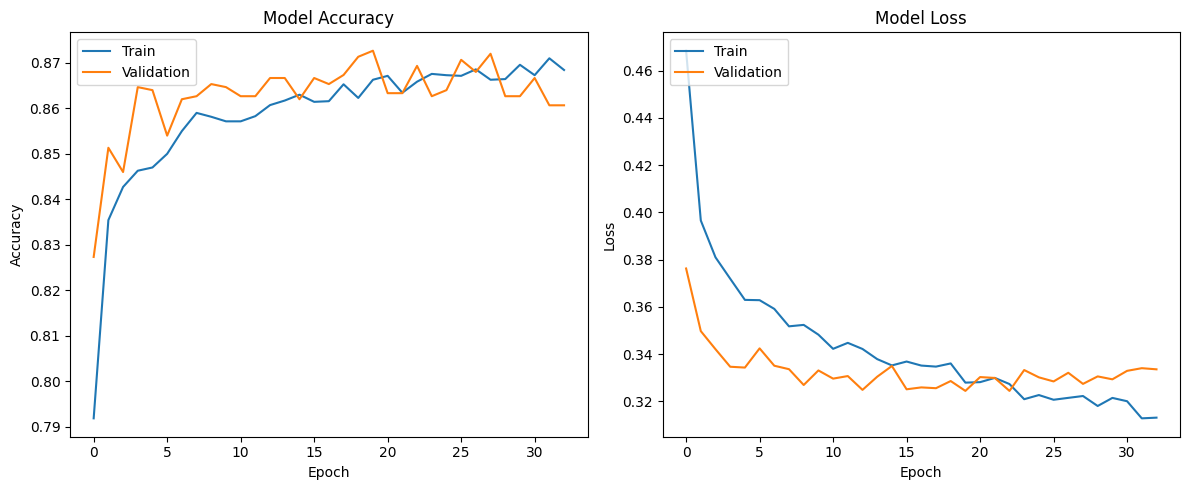

In [57]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()

## Model Building

### Model Evaluation Criterion

Write down the logic for choosing the metric that would be the best metric for this business scenario.

For a churn prediction problem, the choice of evaluation metric is crucial due to the inherent class imbalance (typically, far fewer customers churn than stay) and the business implications of different types of errors.

**Key Considerations:**

1.  **Cost of False Negatives (FN):** A False Negative occurs when the model predicts a customer will *not* churn, but they *actually do*. This is often the most costly error in churn prediction because it represents a lost customer and missed revenue opportunity. The bank loses the customer without having a chance to intervene with retention strategies.
2.  **Cost of False Positives (FP):** A False Positive occurs when the model predicts a customer *will* churn, but they *actually don't*. This results in the bank expending resources on retention efforts for customers who would have stayed anyway. While undesirable, it's typically less costly than a False Negative.

**Choosing the Best Metric:**

*   **Accuracy:** While useful, accuracy can be misleading in imbalanced datasets. A model that predicts no one will churn would achieve a high accuracy if only a small percentage of customers churn, but it would be useless from a business perspective as it would miss all actual churners.

*   **Precision:** Measures the proportion of positive identifications that were actually correct (True Positives / (True Positives + False Positives)). High precision means fewer false alarms. If the bank wants to be very sure that customers identified as churners are indeed churners (to avoid wasting retention efforts), precision is important.

*   **Recall (Sensitivity):** Measures the proportion of actual positives that were correctly identified (True Positives / (True Positives + False Negatives)). High recall means the model is good at catching most of the actual churners. In our scenario, where identifying lost customers is critical, **Recall is a very important metric.**

*   **F1-Score:** This is the harmonic mean of Precision and Recall. It provides a single score that balances both precision and recall. If both false positives and false negatives are important to minimize, but a balance is needed, the **F1-Score is often the best choice.** It's particularly useful when dealing with imbalanced classes because it punishes models that ignore the minority class.

*   **ROC AUC (Receiver Operating Characteristic Area Under the Curve):** Measures the ability of a classifier to distinguish between classes. It provides an aggregate measure of performance across all possible classification thresholds. A higher AUC indicates a better model performance in separating positive and negative classes. This is a robust metric for imbalanced classification as it is insensitive to class distribution.

**Conclusion for this Business Scenario:**

Given that the bank wants to prevent customer churn, **minimizing False Negatives (missing actual churners) is a primary concern**, as these represent direct losses. Therefore, **Recall is a highly critical metric**. However, wasting too many resources on False Positives is also inefficient. Therefore, **F1-Score would be the best single metric** to optimize for, as it balances the need to identify actual churners (recall) with the need to avoid excessive false alarms (precision). Additionally, **ROC AUC** provides a good overall measure of the model's discriminative power.

For direct business impact, we might also consider **Recall at a specific precision level** (e.g., if we can only afford to target a certain number of customers for retention, we want the highest recall within that group).

### Neural Network with SGD Optimizer

Training Neural Network with SGD Optimizer...
Epoch 1/100
349/349 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.5945 - loss: 0.6719 - val_accuracy: 0.7087 - val_loss: 0.6261
Epoch 2/100
349/349 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6798 - loss: 0.6269 - val_accuracy: 0.7287 - val_loss: 0.5676
Epoch 3/100
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7109 - loss: 0.5874 - val_accuracy: 0.7207 - val_loss: 0.5519
Epoch 4/100
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7227 - loss: 0.5651 - val_accuracy: 0.7267 - val_loss: 0.5259
Epoch 5/100
349/349 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7315 - loss: 0.5497 - val_accuracy: 0.7493 - val_loss: 0.4993
Epoch 6/100
349/349 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7440 - loss: 0.5310 - val_accuracy: 0.7273 - val_loss: 0.5187
Epoch 7/100
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7495 - loss: 0.5182 - val_accuracy: 0.7513 - val_loss: 0.4879
Epoch 8/100
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/s

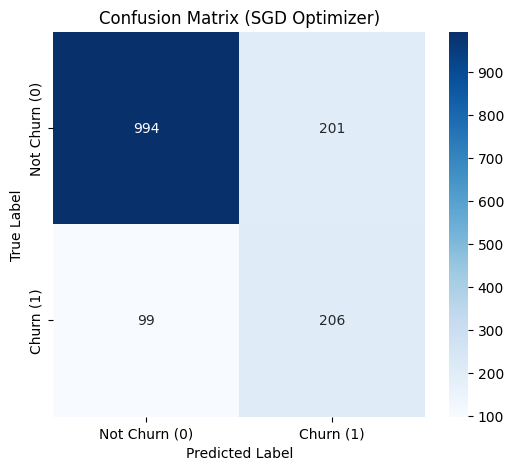


Visualizing Training History:


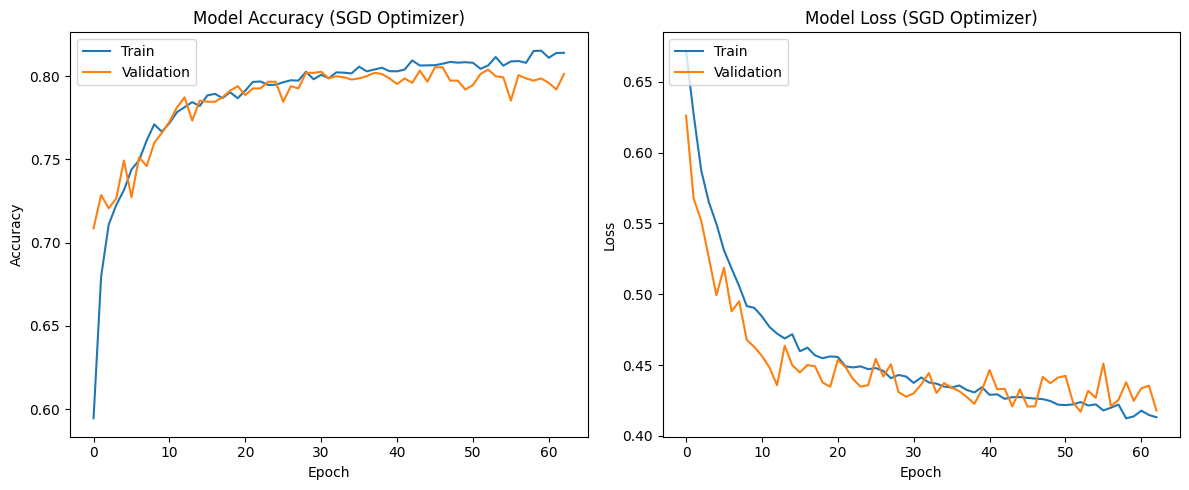

In [70]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define the model architecture
model_sgd = Sequential([
    Input(shape=(X_train_res.shape[1],)), # Recommended way to define input shape
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid') # Output layer for binary classification
])

# Compile the model with SGD optimizer
sgd_optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)
model_sgd.compile(optimizer=sgd_optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Define Early Stopping callback
early_stopping_sgd = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("Training Neural Network with SGD Optimizer...")
# Train the model using SMOTE-balanced data
history_sgd = model_sgd.fit(X_train_res, y_train_res, epochs=100, batch_size=32,
                            validation_data=(X_val, y_val), callbacks=[early_stopping_sgd], verbose=1)

print("Model training complete.")

# --- Model Evaluation ---
print("\nEvaluating Model Performance:")
# Predict probabilities on the test set
y_pred_prob_sgd = model_sgd.predict(X_test)
y_pred_sgd = (y_pred_prob_sgd > 0.5).astype(int)

# Calculate evaluation metrics
accuracy_sgd = accuracy_score(y_test, y_pred_sgd)
precision_sgd = precision_score(y_test, y_pred_sgd)
recall_sgd = recall_score(y_test, y_pred_sgd)
f1_sgd = f1_score(y_test, y_pred_sgd)
roc_auc_sgd = roc_auc_score(y_test, y_pred_prob_sgd)

print(f"Test Accuracy (SGD): {accuracy_sgd:.4f}")
print(f"Test Precision (SGD): {precision_sgd:.4f}")
print(f"Test Recall (SGD): {recall_sgd:.4f}")
print(f"Test F1-Score (SGD): {f1_sgd:.4f}")
print(f"Test ROC AUC (SGD): {roc_auc_sgd:.4f}")

# Display Confusion Matrix
cm_sgd = confusion_matrix(y_test, y_pred_sgd)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_sgd, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churn (0)', 'Churn (1)'],
            yticklabels=['Not Churn (0)', 'Churn (1)'])
plt.title('Confusion Matrix (SGD Optimizer)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# --- Visualize Training History ---
print("\nVisualizing Training History:")
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_sgd.history['accuracy'])
plt.plot(history_sgd.history['val_accuracy'])
plt.title('Model Accuracy (SGD Optimizer)')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_sgd.history['loss'])
plt.plot(history_sgd.history['val_loss'])
plt.title('Model Loss (SGD Optimizer)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()

## Model Performance Improvement

### Neural Network with Adam Optimizer

Training Neural Network with Adam Optimizer...
Epoch 1/100
349/349 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.7348 - loss: 0.5369 - val_accuracy: 0.7727 - val_loss: 0.4688
Epoch 2/100
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7851 - loss: 0.4598 - val_accuracy: 0.7800 - val_loss: 0.4472
Epoch 3/100
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7957 - loss: 0.4452 - val_accuracy: 0.7873 - val_loss: 0.4374
Epoch 4/100
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7999 - loss: 0.4344 - val_accuracy: 0.7993 - val_loss: 0.4267
Epoch 5/100
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8066 - loss: 0.4281 - val_accuracy: 0.8007 - val_loss: 0.4317
Epoch 6/100
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8045 - loss: 0.4243 - val_accuracy: 0.7887 - val_loss: 0.4409
Epoch 7/100
349/349 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8111 - loss: 0.4175 - val_accuracy: 0.8067 - val_loss: 0.4253
Epoch 8/100
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/s

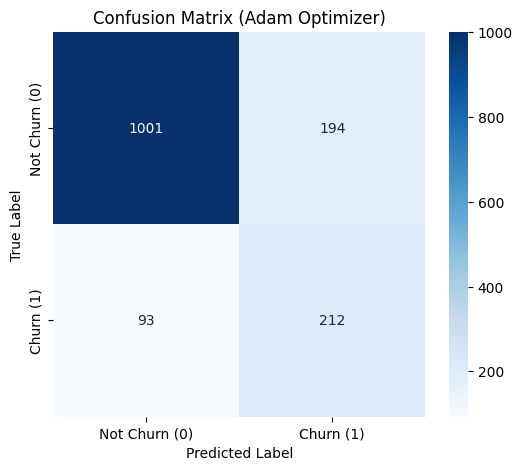


Visualizing Training History:


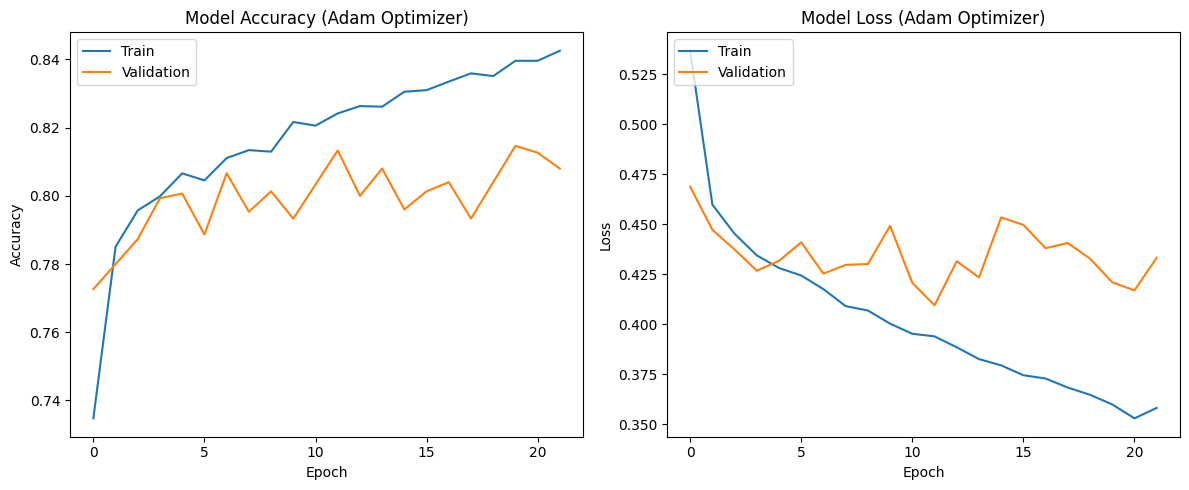

In [71]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define the model architecture
model_adam = Sequential([
    Input(shape=(X_train_res.shape[1],)), # Explicitly define input shape
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid') # Output layer for binary classification
])

# Compile the model with Adam optimizer
model_adam.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Define Early Stopping callback
early_stopping_adam = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("Training Neural Network with Adam Optimizer...")
# Train the model using SMOTE-balanced data
history_adam = model_adam.fit(X_train_res, y_train_res, epochs=100, batch_size=32,
                             validation_data=(X_val, y_val), callbacks=[early_stopping_adam], verbose=1)

print("Model training complete.")

# --- Model Evaluation ---
print("\nEvaluating Model Performance:")
# Predict probabilities on the test set
y_pred_prob_adam = model_adam.predict(X_test)
y_pred_adam = (y_pred_prob_adam > 0.5).astype(int)

# Calculate evaluation metrics
accuracy_adam = accuracy_score(y_test, y_pred_adam)
precision_adam = precision_score(y_test, y_pred_adam)
recall_adam = recall_score(y_test, y_pred_adam)
f1_adam = f1_score(y_test, y_pred_adam)
roc_auc_adam = roc_auc_score(y_test, y_pred_prob_adam)

print(f"Test Accuracy (Adam): {accuracy_adam:.4f}")
print(f"Test Precision (Adam): {precision_adam:.4f}")
print(f"Test Recall (Adam): {recall_adam:.4f}")
print(f"Test F1-Score (Adam): {f1_adam:.4f}")
print(f"Test ROC AUC (Adam): {roc_auc_adam:.4f}")

# Display Confusion Matrix
cm_adam = confusion_matrix(y_test, y_pred_adam)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_adam, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churn (0)', 'Churn (1)'],
            yticklabels=['Not Churn (0)', 'Churn (1)'])
plt.title('Confusion Matrix (Adam Optimizer)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# --- Visualize Training History ---
print("\nVisualizing Training History:")
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_adam.history['accuracy'])
plt.plot(history_adam.history['val_accuracy'])
plt.title('Model Accuracy (Adam Optimizer)')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_adam.history['loss'])
plt.plot(history_adam.history['val_loss'])
plt.title('Model Loss (Adam Optimizer)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()

### Neural Network with Adam Optimizer and Dropout

### Analyse de la Matrice de Confusion (Optimiseur Adam)

La matrice de confusion pour le modèle avec l'optimiseur Adam est la suivante :

```
[[1001,  194],
 [  93,  212]]
```

Interprétons cette matrice :

*   **Vrais Négatifs (True Negatives - TN) : 1001**
    *   Ce sont les clients qui n'ont **pas déserté** et que le modèle a correctement prédit comme ne désertant **pas**.
    *   C'est un bon résultat, indiquant que le modèle est capable d'identifier correctement les clients fidèles.

*   **Faux Positifs (False Positives - FP) : 194**
    *   Ce sont les clients qui n'ont **pas déserté** (True Label = 0), mais que le modèle a prédit à tort comme étant des déserteurs (**Churn (1)**).
    *   Ces cas représentent des ressources (marketing, offres spéciales) qui pourraient être gaspillées sur des clients qui n'avaient pas l'intention de partir. Leur coût est généralement financier mais moins critique que les Faux Négatifs.

*   **Faux Négatifs (False Negatives - FN) : 93**
    *   Ce sont les clients qui ont **déserté** (True Label = 1), mais que le modèle a prédit à tort comme ne désertant **pas** (**Not Churn (0)**).
    *   C'est l'erreur la plus coûteuse dans le contexte de la prédiction de désabonnement, car elle signifie que la banque a manqué l'opportunité d'intervenir et de retenir ces clients. **Un nombre élevé de Faux Négatifs est problématique pour cet objectif commercial.**

*   **Vrais Positifs (True Positives - TP) : 212**
    *   Ce sont les clients qui ont **déserté** et que le modèle a correctement prédit comme étant des déserteurs.
    *   Ces cas sont cruciaux car ils permettent à la banque d'activer des stratégies de rétention pour tenter de les conserver.

**En résumé :**

Le modèle Adam a identifié 212 vrais déserteurs (TP) et 1001 vrais non-déserteurs (TN). Cependant, il a manqué 93 déserteurs réels (FN) et a identifié à tort 194 non-déserteurs comme étant des déserteurs (FP). Le **rappel de 0.6951** (212 / (212 + 93)) montre que le modèle a capturé environ 69.5% des clients qui ont réellement déserté. La **précision de 0.5222** (212 / (212 + 194)) indique qu'environ 52.2% des clients que le modèle a prédit comme déserteurs l'étaient réellement. Ces métriques sont un équilibre entre l'identification des déserteurs et la minimisation des faux positifs, ce qui est souvent souhaitable dans les problèmes de déséquilibre de classe.

### Neural Network with Balanced Data (by applying SMOTE) and SGD Optimizer

### Neural Network with Balanced Data (by applying SMOTE) and Adam Optimizer

### Neural Network with Balanced Data (by applying SMOTE), Adam Optimizer, and Dropout

## Model Performance Comparison and Final Model Selection

## Actionable Insights and Business Recommendations

*



<font size=6 color='blue'>Power Ahead</font>
___